# GCC118 - Programação Matemática
## Universidade Federal de Lavras
### Instituto de Ciências Exatas e Tecnológicas
#### Lucio Vargas de Albuquerque Nunes

## Problema

Uma empresa de aço produz **placas** e **canos de ferro**.

As taxas de produção são:

- **200 T/h** para placas;
- **140 T/h** para canos.

O lucro obtido é de:

- **US$ 25/T** para placas;
- **US$ 30/T** para canos.

Considerando a demanda atual, os limites de produção semanal são:

- **6000 T** de placas;
- **4000 T** de canos.

A jornada de produção semanal é de **40 horas**.

### Pergunta

Quantas toneladas de placas e canos devem ser produzidas para **maximizar o lucro**?

### Referências

Lista de exercícios — *Modelagem Matemática e Método Simplex*.

Professores **Andreza Beezão** e **Mayron Moreira**.

## Instalação da biblioteca PuLP

Para mais informações, acesse: [PuLP
](https://pypi.org/project/PuLP/).

In [ ]:
!pip install pulp
import pulp



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys

print(sys.executable)

/home/lucio/github/alura/pipeline_dados/venv/bin/python


In [3]:
lucro = [25, 30]

limite_producao = [6000, 4000]

tempo = [
    1 / 200,  # horas por tonelada de placas
    1 / 140   # horas por tonelada de canos
]

jornada = 40

## Declaração do objeto que representa o modelo matemático

In [4]:
modelo = pulp.LpProblem("producao_aco", pulp.LpMaximize)

In [5]:
x = [
    pulp.LpVariable("placas", lowBound=0),
    pulp.LpVariable("canos", lowBound=0)
]

In [6]:
# ==========================================================
# FUNÇÃO OBJETIVO
# ==========================================================

modelo += pulp.lpSum(
    lucro[i] * x[i]
    for i in range(2)
)

In [7]:
# ==========================================================
# RESTRIÇÕES
# ==========================================================

# Limites de produção
for i in range(2):
    modelo += x[i] <= limite_producao[i]

# Jornada semanal
modelo += pulp.lpSum(
    tempo[i] * x[i]
    for i in range(2)
) <= jornada

### Resolvendo o problema

In [8]:
# ==========================================================
# SOLUÇÃO
# ==========================================================

modelo.solve()

print("Status:", pulp.LpStatus[modelo.status])
print()

print("Solução ótima:")
print(f"Placas: {x[0].varValue:.2f} T")
print(f"Canos: {x[1].varValue:.2f} T")
print()

print(
    f"Lucro máximo: US$ {pulp.value(modelo.objective):,.2f}"
)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/lucio/github/alura/pipeline_dados/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/d4c6193978c4442f856d983bddc26b6e-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /tmp/d4c6193978c4442f856d983bddc26b6e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 15 RHS
At line 19 BOUNDS
At line 20 ENDATA
Problem MODEL has 3 rows, 2 columns and 4 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1 (-2) rows, 2 (0) columns and 2 (-2) elements
0  Obj -0 Dual inf 65.714284 (2)
1  Obj 192000
Optimal - objective value 192000
After Postsolve, objective 192000, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 192000 - 1 iterations time 0.002, Presolve 0.00
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00 

## Imprimindo as soluções do problema

In [9]:
# ==========================================================
# SOLUÇÃO
# ==========================================================

modelo.solve()

print("Status:", pulp.LpStatus[modelo.status])
print()

print("Solução ótima:")
print(f"Placas: {x[0].varValue:.2f} T")
print(f"Canos: {x[1].varValue:.2f} T")
print()

print(
    f"Lucro máximo: US$ {pulp.value(modelo.objective):,.2f}"
)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/lucio/github/alura/pipeline_dados/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/f67da434e93f417f91a16d5952219b31-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /tmp/f67da434e93f417f91a16d5952219b31-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 15 RHS
At line 19 BOUNDS
At line 20 ENDATA
Problem MODEL has 3 rows, 2 columns and 4 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1 (-2) rows, 2 (0) columns and 2 (-2) elements
0  Obj -0 Dual inf 65.714284 (2)
1  Obj 192000
Optimal - objective value 192000
After Postsolve, objective 192000, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 192000 - 1 iterations time 0.002, Presolve 0.00
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00 

In [17]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12

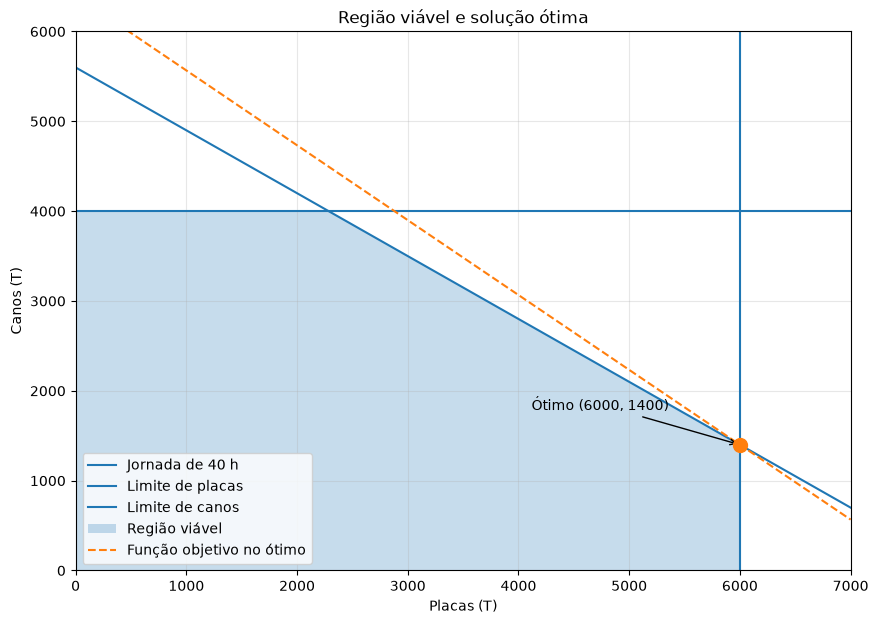

In [18]:
import matplotlib.pyplot as plt

# ==========================================================
# GRÁFICO
# ==========================================================

# Valores de x1 de 0 até 7000
x1 = [
    i * 7000 / 499
    for i in range(500)
]

# Restrição de jornada:
# x1/200 + x2/140 = 40
x2_tempo = [
    140 * (40 - valor / 200)
    for valor in x1
]

# Função objetivo no valor ótimo:
# 25*x1 + 30*x2 = 192000
lucro_otimo = pulp.value(
    modelo.objective
)

x2_lucro = [
    (lucro_otimo - 25 * valor) / 30
    for valor in x1
]

# ==========================================================
# VÉRTICES DA REGIÃO VIÁVEL
# ==========================================================

vertices_x = [
    0,
    6000,
    6000,
    2285.71,
    0
]

vertices_y = [
    0,
    0,
    1400,
    4000,
    4000
]

# ==========================================================
# GRÁFICO
# ==========================================================

plt.figure(
    figsize=(10, 7)
)

# Restrição de tempo
plt.plot(
    x1,
    x2_tempo,
    label="Jornada de 40 h"
)

# Limites de produção
plt.axvline(
    6000,
    label="Limite de placas"
)

plt.axhline(
    4000,
    label="Limite de canos"
)

# Região viável
plt.fill(
    vertices_x,
    vertices_y,
    alpha=0.25,
    label="Região viável"
)

# Reta da função objetivo no ótimo
plt.plot(
    x1,
    x2_lucro,
    linestyle="--",
    label="Função objetivo no ótimo"
)

# ==========================================================
# SOLUÇÃO ÓTIMA
# ==========================================================

placas = x[0].varValue
canos = x[1].varValue

plt.scatter(
    placas,
    canos,
    s=100,
    zorder=5
)

plt.annotate(
    f"Ótimo ({placas:.0f}, {canos:.0f})",
    (placas, canos),
    xytext=(-150, 25),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    }
)

# ==========================================================
# FORMATAÇÃO
# ==========================================================

plt.xlim(
    0,
    7000
)

plt.ylim(
    0,
    6000
)

plt.xlabel(
    "Placas (T)"
)

plt.ylabel(
    "Canos (T)"
)

plt.title(
    "Região viável e solução ótima"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()